# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# The dataset is provided directly at '/content/dataset_heart.csv', so zip extraction is not needed.
# ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
# EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# List CSV files under EXTRACT_DIR (not needed as the path is direct)
csv_path = 'dataset_heart.csv'  # set to the CSV you choose

# Load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# Inspect df
print('DataFrame Info:')
df.info()
print('\nFirst 5 rows of the DataFrame:')
display(df.head())
print('\nDataFrame Description:')
display(df.describe())

# Identify target column
target = 'heart disease'
print(f"\nTarget column identified as: '{target}'")

# Split features and target
X = df.drop(columns=[target])
y = df[target]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels 

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



DataFrame Description:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000



Target column identified as: 'heart disease'

Features (X) shape: (270, 13)
Target (y) shape: (270,)

X_train shape: (216, 13)
X_test shape: (54, 13)
y_train shape: (216,)
y_test shape: (54,)


### Basic visual checks

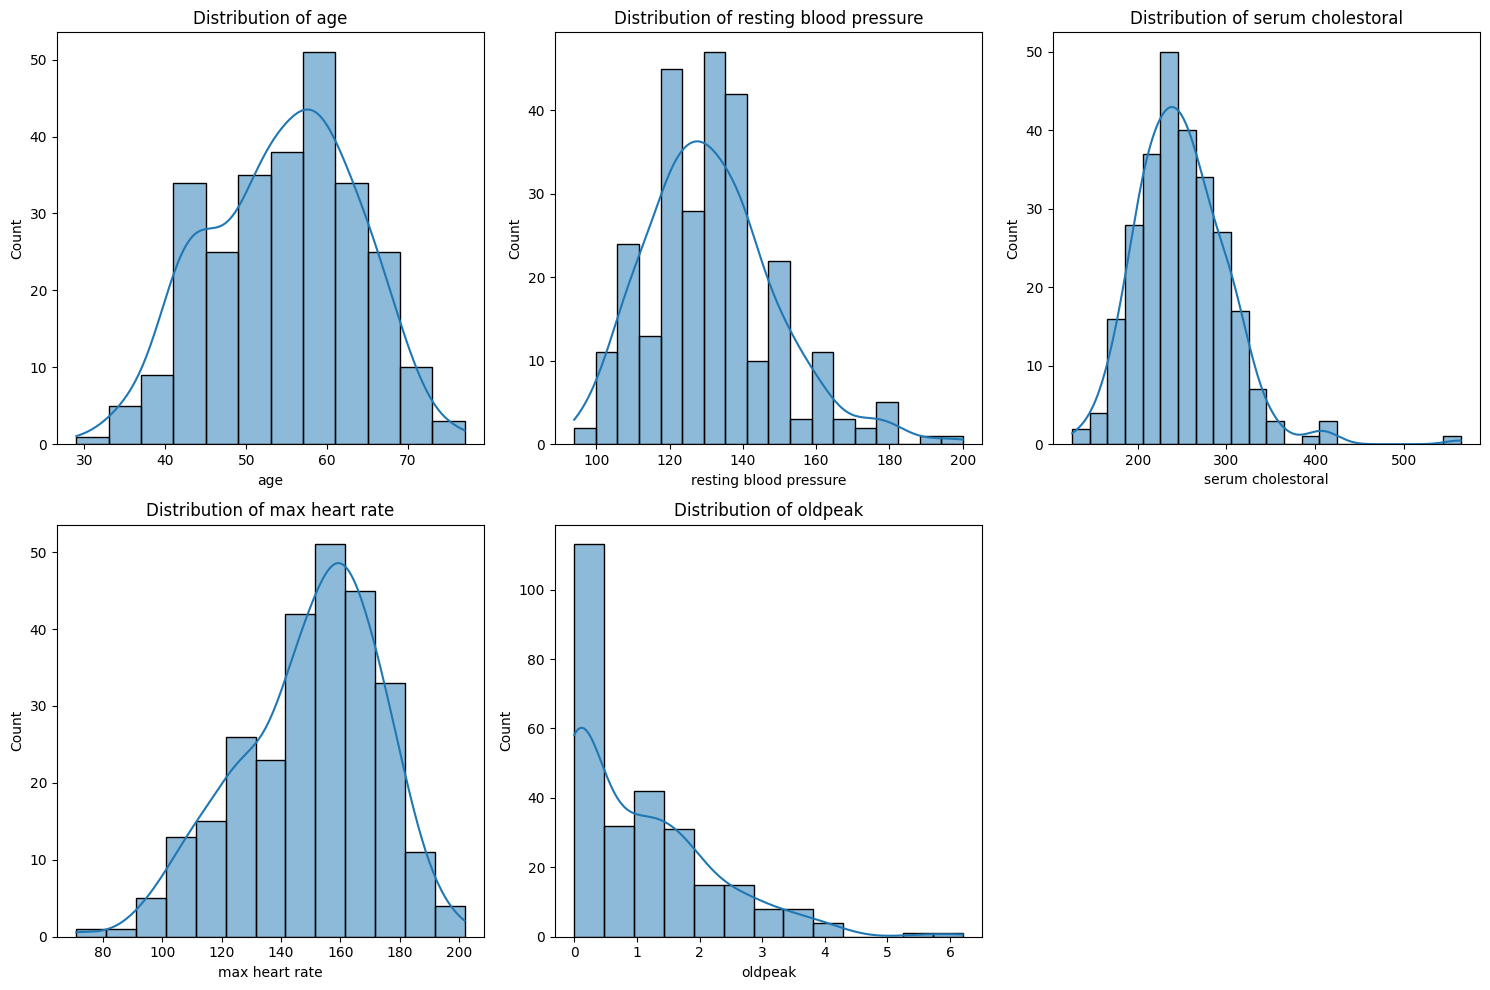

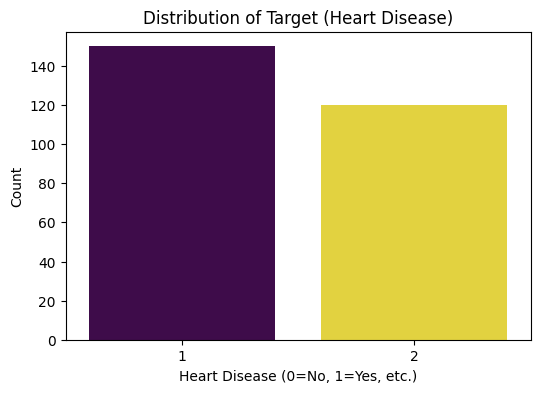

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for selected numeric columns
numeric_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Plot class balance as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df, palette='viridis', hue=target, legend=False)
plt.title('Distribution of Target (Heart Disease)')
plt.xlabel('Heart Disease (0=No, 1=Yes, etc.)') # Adjust labels based on actual target values if known
plt.ylabel('Count')
plt.show()

## Preprocessing pipeline

In [5]:
cat_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'major vessels', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

# Build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

## Helper - evaluation function

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # Predictions
    y_pred = model.predict(X_test)

    # Compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted'),
    }
    print(f"{name}: Metrics: {metrics}")

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)
        # For multi-class, ROC AUC is typically calculated per class or macro/micro averaged
        # For binary classification (assuming 2 classes for simplicity, target values 1 and 2 in the dataset)
        # We'll plot ROC for class 2 (positive class if 1 is negative, or vice-versa)
        # Note: dataset target values are 1 and 2, remapping to 0 and 1 for typical ROC curve
        y_test_binary = np.where(y_test == 2, 1, 0) # Assuming 2 is the 'positive' class and 1 is 'negative'
        y_prob_positive = y_prob[:, 1] # Probability of the second class (index 1)

        fpr, tpr, _ = roc_curve(y_test_binary, y_prob_positive)
        roc_auc = roc_auc_score(y_test_binary, y_prob_positive)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {name}')
        plt.legend(loc="lower right")
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (no grid search): Metrics: {'accuracy': 0.8703703703703703, 'precision': 0.8765432098765431, 'recall': 0.8703703703703703, 'f1': 0.8707717004930627}


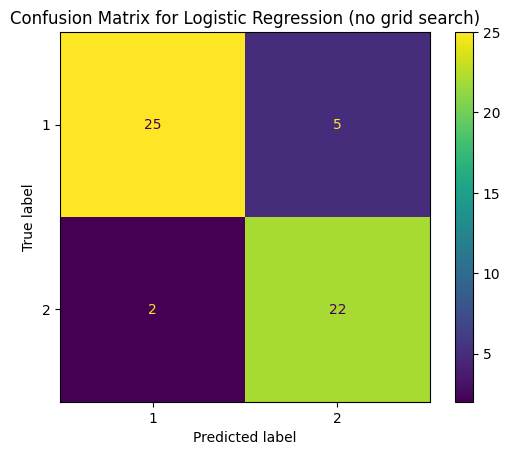

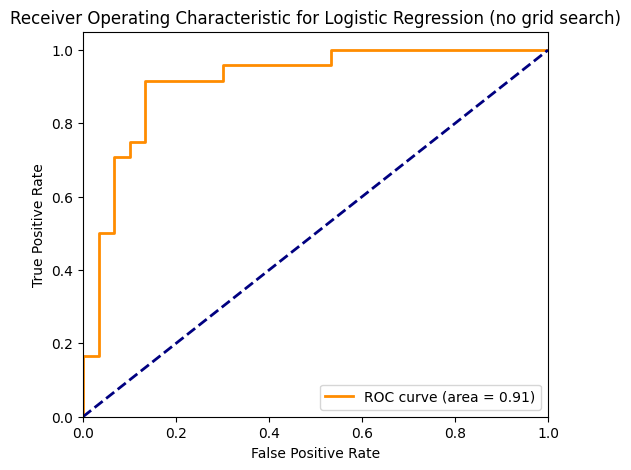

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

# Ensure feature names are cleaned so the preprocessor column lists match
X_train = X_train.rename(columns=str.strip)
X_test = X_test.rename(columns=str.strip)

# Create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000))
])

# Fit on training data
pipe_lr.fit(X_train, y_train)

# Evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (no grid search)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Logistic Regression (grid search): Metrics: {'accuracy': 0.8703703703703703, 'precision': 0.8765432098765431, 'recall': 0.8703703703703703, 'f1': 0.8707717004930627}


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


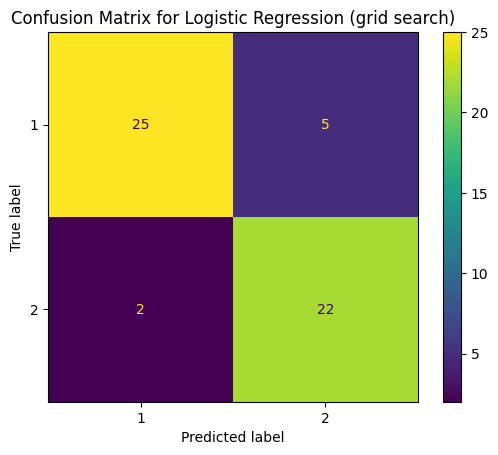

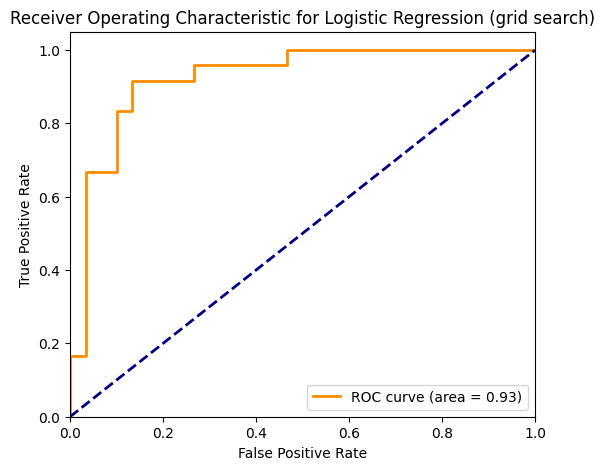

In [8]:
# Build a Pipeline similar to above for GridSearchCV
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000))
])

# Define param_grid for 'classifier__C' and 'classifier__penalty'
# Note the double underscore to refer to hyperparameters within the pipeline step
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
}

# GridSearchCV with cv=5 and scoring='f1' (or 'accuracy' or 'roc_auc' based on problem)
# We'll use 'f1_weighted' since we have a multi-class target and want a balanced metric
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('Logistic Regression (grid search)', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

SVM (no grid search): Metrics: {'accuracy': 0.8518518518518519, 'precision': 0.8620268620268621, 'recall': 0.8518518518518519, 'f1': 0.8522588522588521}


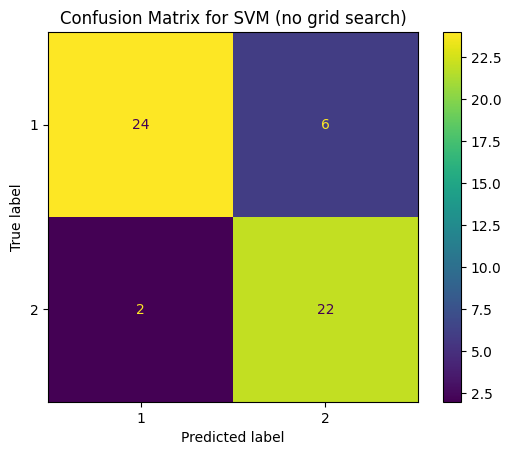

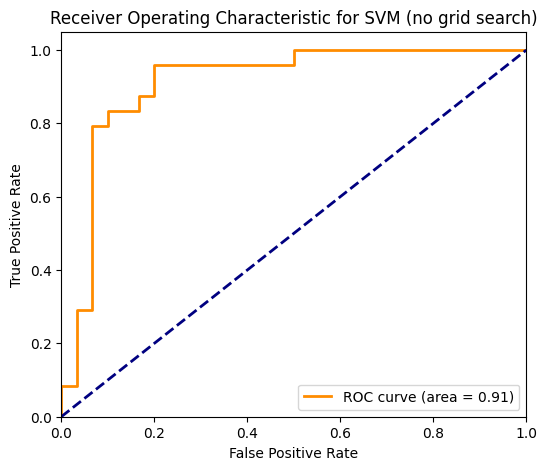

In [9]:
# Exercise 4 - SVM without Grid Search
# Create a Pipeline with your preprocessor and SVC
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True))
])

# Fit on training data
pipe_svm.fit(X_train, y_train)

# Evaluate
svm_no_metrics = eval_and_report('SVM (no grid search)', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
SVM (grid search): Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.8395061728395061, 'recall': 0.8333333333333334, 'f1': 0.8338493292053664}


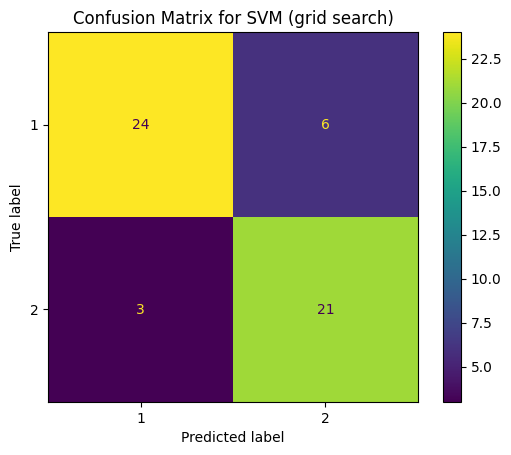

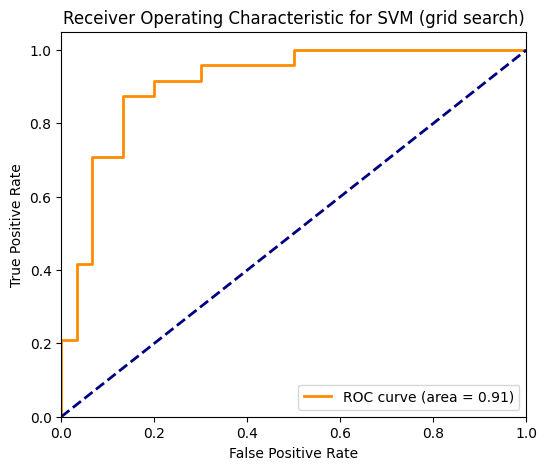

In [10]:
# Exercise 5 - SVM with Grid Search
# Pipeline with SVC(probability=True) pour pouvoir tracer la courbe ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# Param grid pour svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
}

# GridSearchCV
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM (grid search)', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGBoost (no grid search): Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.8344827586206897, 'recall': 0.8333333333333334, 'f1': 0.8336215842269111}


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:22:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


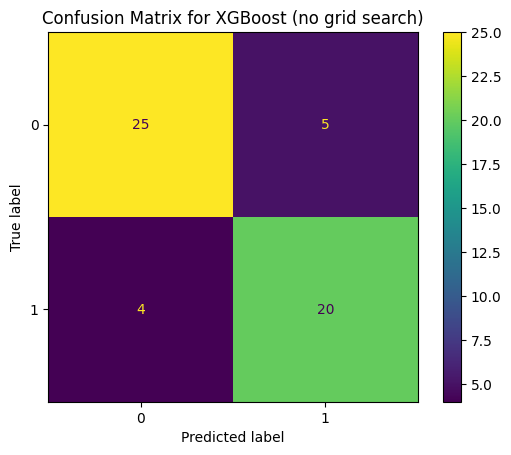

c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


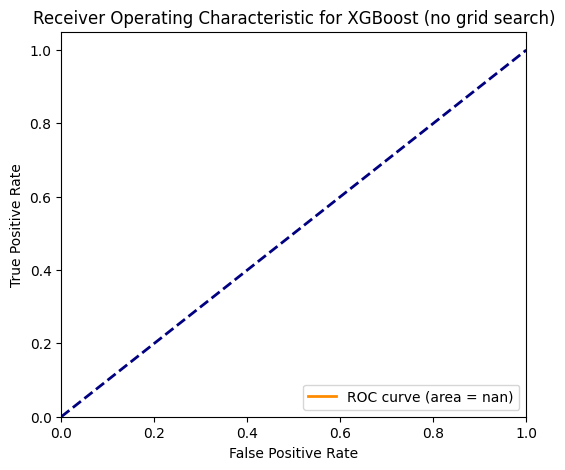

In [11]:
# Exercise 6 - XGBoost without Grid Search
if XGBClassifier is None:
    print('XGBoost non disponible, installer avec: !pip install xgboost')
else:
    pipe_xgb = Pipeline(steps=[
        ('preprocessor', pre),
        ('xgb', XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=4,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            use_label_encoder=False
        ))
    ])

    # Fit on training data
    y_train_xgb = (y_train == 2).astype(int)
    y_test_xgb = (y_test == 2).astype(int)

    pipe_xgb.fit(X_train, y_train_xgb)

    xgb_no_metrics = eval_and_report('XGBoost (no grid search)', pipe_xgb, X_test, y_test_xgb)


## Exercise 7 - XGBoost with Grid Search

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:22:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 500, 'xgb__subsample': 0.9}
XGBoost (grid search): Metrics: {'accuracy': 0.8148148148148148, 'precision': 0.818070818070818, 'recall': 0.8148148148148148, 'f1': 0.8153256704980844}


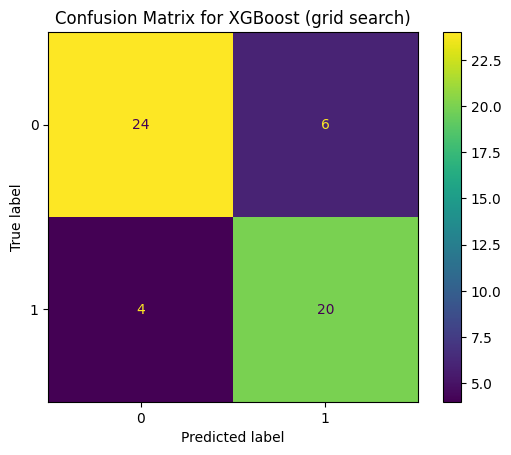

c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


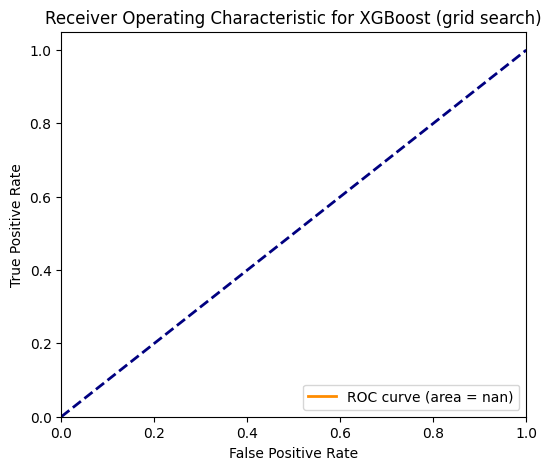

In [12]:
# Exercise 7 - XGBoost with Grid Search
if XGBClassifier is None:
    print('XGBoost non disponible, installer avec: !pip install xgboost')
else:
    pipe_xgb_cv = Pipeline(steps=[
        ('preprocessor', pre),
        ('xgb', XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            use_label_encoder=False
        ))
    ])

    # Param grid
    xgb_param_grid = {
        'xgb__n_estimators': [100, 300, 500],
        'xgb__learning_rate': [0.01, 0.05, 0.1],
        'xgb__max_depth': [3, 4, 5],
        'xgb__subsample': [0.7, 0.9, 1.0],
        'xgb__colsample_bytree': [0.7, 0.9, 1.0],
    }

    # GridSearchCV
    grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
    grid_xgb.fit(X_train, y_train_xgb)

    print('Best params:', grid_xgb.best_params_)
    best_xgb = grid_xgb.best_estimator_
    xgb_gs_metrics = eval_and_report('XGBoost (grid search)', best_xgb, X_test, y_test_xgb)


## Compare models


=== Rapport de comparaison des modèles ===


,accuracy,precision,recall,f1
LR no grid,0.8704,0.8765,0.8704,0.8708
LR grid search,0.8704,0.8765,0.8704,0.8708
SVM no grid,0.8519,0.8620,0.8519,0.8523
SVM grid search,0.8333,0.8395,0.8333,0.8338
XGB no grid,0.8333,0.8345,0.8333,0.8336
XGB grid search,0.8148,0.8181,0.8148,0.8153


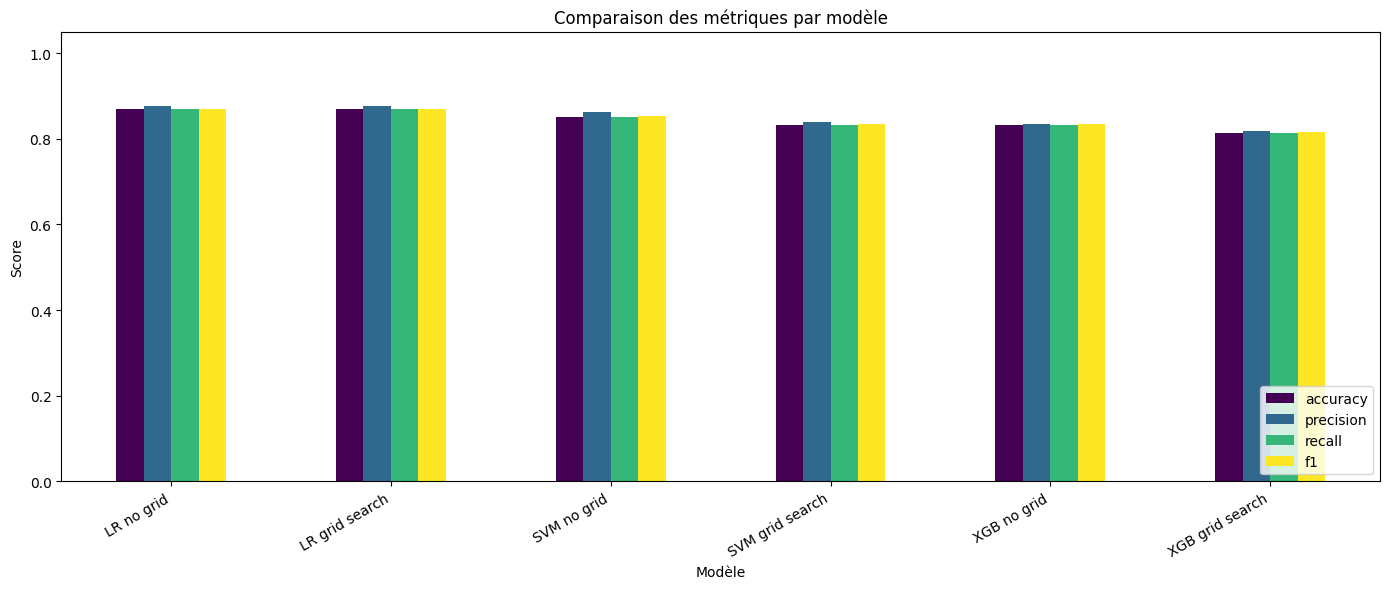


Meilleur modèle (F1-score) : LR no grid → F1 = 0.8708


In [13]:
# Comparaison de tous les modèles
summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid search'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid search'] = svm_gs_metrics

# Ajouter XGBoost si disponible
if XGBClassifier is not None:
    summary['XGB no grid'] = xgb_no_metrics
    summary['XGB grid search'] = xgb_gs_metrics

# Créer un DataFrame de comparaison
comparison_df = pd.DataFrame.from_dict(summary, orient='index')
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('f1', ascending=False)

print('\n=== Rapport de comparaison des modèles ===')
display(comparison_df)

# Visualisation en barres
comparison_df.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Comparaison des métriques par modèle')
plt.xlabel('Modèle')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Meilleur modèle selon F1
best_model_name = comparison_df['f1'].idxmax()
print(f'\nMeilleur modèle (F1-score) : {best_model_name} → F1 = {comparison_df.loc[best_model_name, "f1"]:.4f}')
